In [1]:
#reading json files
import json

with open('Coord.json') as a, open('Cost.json') as b, open('Dist.json') as c, open('G.json') as d:
    Coord = json.load(a)
    Cost = json.load(b)
    Dist = json.load(c)
    G = json.load(d)


In [98]:
print(Coord['1'])
print(Cost['1,2'])
print(Dist['1,2'])
print(G['1'])

[-73530767, 41085396]
2008
803
['1363', '12', '2']


Shortest path: 1->1363->1358->1357->1356->1276->1273->1277->1269->1267->1268->1284->1283->1282->1255->1253->1260->1259->1249->1246->963->964->962->1002->952->1000->998->994->995->996->987->988->979->980->969->977->989->990->991->2369->2366->2340->2338->2339->2333->2334->2329->2029->2027->2019->2022->2000->1996->1997->1993->1992->1989->1984->2001->1900->1875->1874->1965->1963->1964->1923->1944->1945->1938->1937->1939->1935->1931->1934->1673->1675->1674->1837->1671->1828->1825->1817->1815->1634->1814->1813->1632->1631->1742->1741->1740->1739->1591->1689->1585->1584->1688->1579->1679->1677->104->5680->5418->5431->5425->5424->5422->5413->5412->5411->66->5392->5391->5388->5291->5278->5289->5290->5283->5284->5280->50
Shortest distance: 148648.63722140007

Dijkstra explored: 5304 nodes | distance: 148648.63722140007
A* explored:       1225 nodes | distance: 148648.63722140007
Same path: True


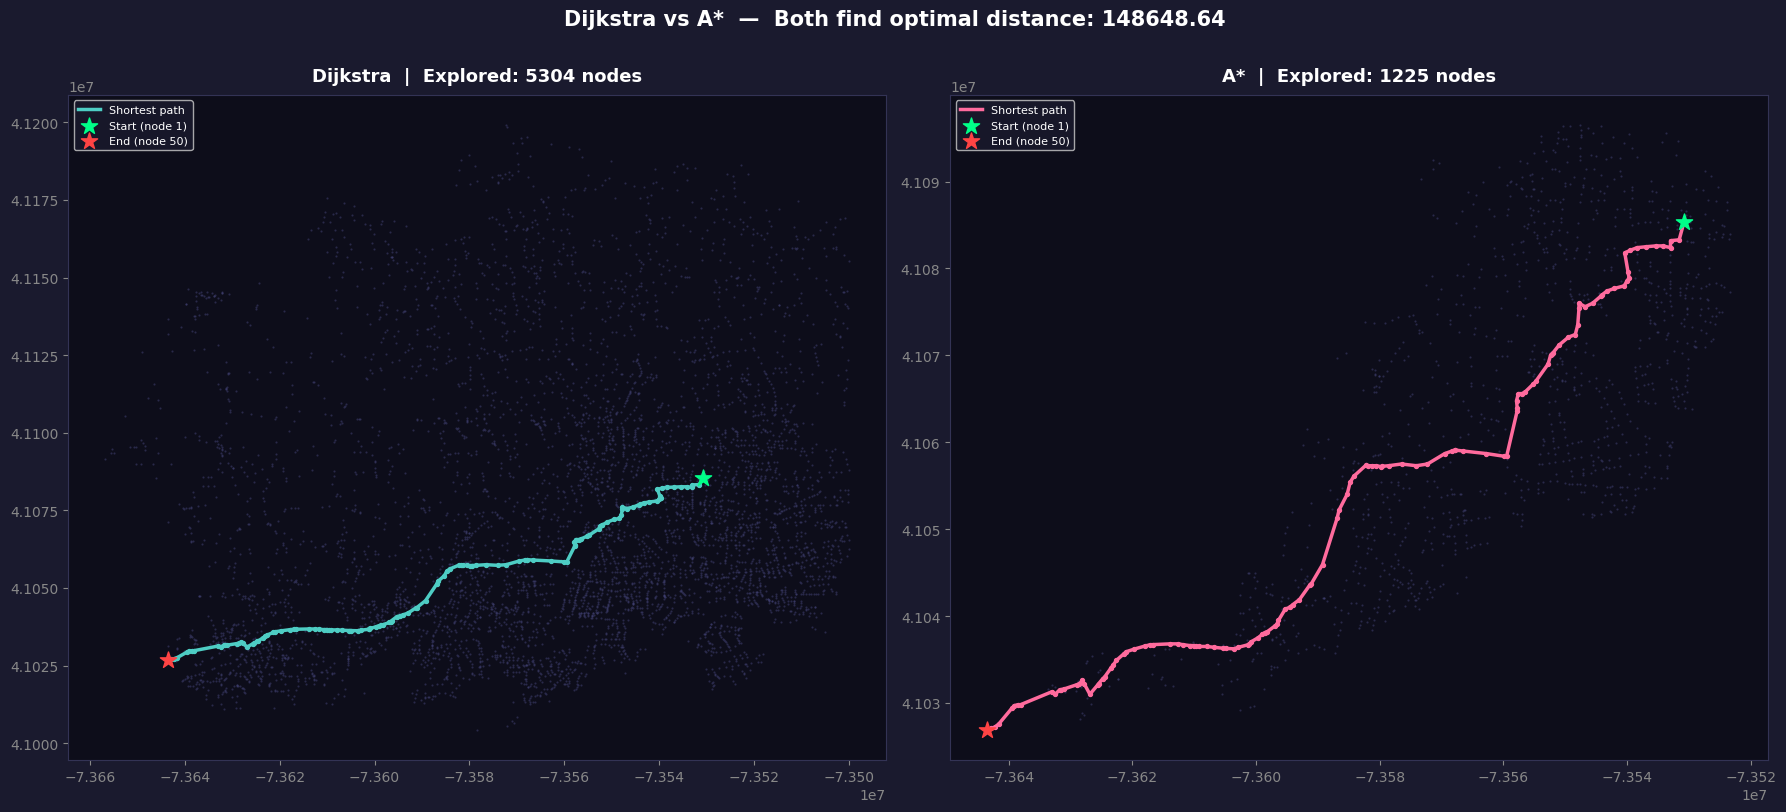

In [2]:
import heapq
import math
import matplotlib.pyplot as plt

start = '1'
goal = '50'

def heuristic(node, goal, Coord):
    x1, y1 = Coord[node]
    x2, y2 = Coord[goal]
    return math.sqrt((x1-x2)**2 + (y1-y2)**2)

def dijkstra(G, Dist, start, goal):
    heap = [(0, 0, start)]
    counter = 0
    visited = set()
    prev = {start: None}
    g_score = {start: 0}
    while heap:
        g, _, node = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)
        if node == goal:
            break
        for neighbour in G.get(node, []):
            if neighbour in visited:
                continue
            edge_dist = Dist.get(f'{node},{neighbour}')
            if edge_dist is None:
                continue
            new_g = g + edge_dist
            if new_g < g_score.get(neighbour, float('inf')):
                g_score[neighbour] = new_g
                prev[neighbour] = node
                counter += 1
                heapq.heappush(heap, (new_g, counter, neighbour))
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = prev.get(node)
    path.reverse()
    return path, g_score.get(goal, float('inf')), visited

def astar(G, Dist, Coord, start, goal):
    heap = [(heuristic(start, goal, Coord), 0, 0, start)]
    counter = 0
    visited = set()
    prev = {start: None}
    g_score = {start: 0}
    while heap:
        f, _, g, node = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)
        if node == goal:
            break
        for neighbour in G.get(node, []):
            if neighbour in visited:
                continue
            edge_dist = Dist.get(f'{node},{neighbour}')
            if edge_dist is None:
                continue
            new_g = g + edge_dist
            if new_g < g_score.get(neighbour, float('inf')):
                g_score[neighbour] = new_g
                prev[neighbour] = node
                counter += 1
                heapq.heappush(heap, (new_g + heuristic(neighbour, goal, Coord), counter, new_g, neighbour))
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = prev.get(node)
    path.reverse()
    return path, g_score.get(goal, float('inf')), visited


# --- run both ---
d_path, d_dist, d_visited = dijkstra(G, Dist, start, goal)
a_path, a_dist, a_visited = astar(G, Dist, Coord, start, goal)

print(f"Shortest path: {'->'.join(a_path)}")
print(f"Shortest distance: {a_dist}")
print(f"\nDijkstra explored: {len(d_visited)} nodes | distance: {d_dist}")
print(f"A* explored:       {len(a_visited)} nodes | distance: {a_dist}")
print(f"Same path: {d_path == a_path}")

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')

for ax, explored, path, title, color in zip(
    axes,
    [d_visited, a_visited],
    [d_path, a_path],
    [f'Dijkstra  |  Explored: {len(d_visited)} nodes', f'A*  |  Explored: {len(a_visited)} nodes'],
    ['#4ecdc4', '#ff6b9d']
):
    ax.set_facecolor('#0d0d1a')
    ex = [Coord[n][0] for n in explored if n in Coord]
    ey = [Coord[n][1] for n in explored if n in Coord]
    ax.scatter(ex, ey, s=0.3, c='#444477', alpha=0.5, zorder=1)
    px = [Coord[n][0] for n in path if n in Coord]
    py = [Coord[n][1] for n in path if n in Coord]
    ax.plot(px, py, color=color, linewidth=2.5, zorder=3, label='Shortest path')
    ax.scatter(px, py, s=8, c=color, zorder=4)
    ax.scatter(*Coord[start], s=150, c='#00ff88', zorder=5, marker='*', label='Start (node 1)')
    ax.scatter(*Coord[goal],  s=150, c='#ff4444', zorder=5, marker='*', label='End (node 50)')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(colors='#888888')
    ax.legend(loc='upper left', fontsize=8, facecolor='#1a1a2e', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

fig.suptitle(f'Dijkstra vs A*  —  Both find optimal distance: {round(a_dist, 2)}',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()